In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

train_data =fetch_20newsgroups(
    subset="train",
    remove=("headers","footers","quotes")
)

In [11]:
test_data=fetch_20newsgroups(
    subset="test",
    remove=("headers","footers","quotes")
)

In [14]:
X_train_text=train_data.data
y_train=train_data.target
X_test_text=test_data.data
y_test=test_data.target
class_names=train_data.target_names

In [17]:
print("Training documents",len(X_train_text))
print("Testing documents",len(X_test_text))
print("Number of classes:",len(class_names))

Training documents 11314
Testing documents 7532
Number of classes: 20


In [21]:
vectorizer=CountVectorizer(
    stop_words="english",
    min_df=2
)
X_train=vectorizer.fit_transform(X_train_text)
X_test=vectorizer.transform(X_test_text)

In [23]:
print("Training feature matrix:",X_train.shape)
print("Testing feature matrix",X_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix (7532, 39115)


In [25]:
mnb=MultinomialNB()
mnb.fit(
    X_train,
    y_train
)
y_pred_mnb=mnb.predict(X_test)

In [30]:
binary_vectorizer=CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary=binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary=binary_vectorizer.transform(
    X_test_text
)

In [48]:
bnb=BernoulliNB()
bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb=bnb.predict(
    X_test_binary
)

In [50]:
# Calculate evaluation metrics for Multinomial Naive Bayes
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
mnb_precision = precision_score(y_test, y_pred_mnb, average="weighted", zero_division=0)
mnb_recall = recall_score(y_test, y_pred_mnb, average="weighted", zero_division=0)
mnb_f1 = f1_score(y_test, y_pred_mnb, average="weighted", zero_division=0)

# Calculate evaluation metrics for Bernoulli Naive Bayes
bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_precision = precision_score(y_test, y_pred_bnb, average="weighted", zero_division=0)
bnb_recall = recall_score(y_test, y_pred_bnb, average="weighted", zero_division=0)
bnb_f1 = f1_score(y_test, y_pred_bnb, average="weighted", zero_division=0)


In [51]:
results_table = pd.DataFrame({
    "Model": ["Multinomial NB", "Bernoulli NB"],
    "Accuracy": [mnb_accuracy, bnb_accuracy],
    "Precision": [mnb_precision, bnb_precision],
    "Recall": [mnb_recall, bnb_recall],
    "F1-score": [mnb_f1, bnb_f1]
})

# Round values for easier reading
results_table = results_table.round(4)

print(results_table)

            Model  Accuracy  Precision  Recall  F1-score
0  Multinomial NB    0.6511     0.6425  0.6511    0.6296
1    Bernoulli NB    0.4851     0.6270  0.4851    0.4808


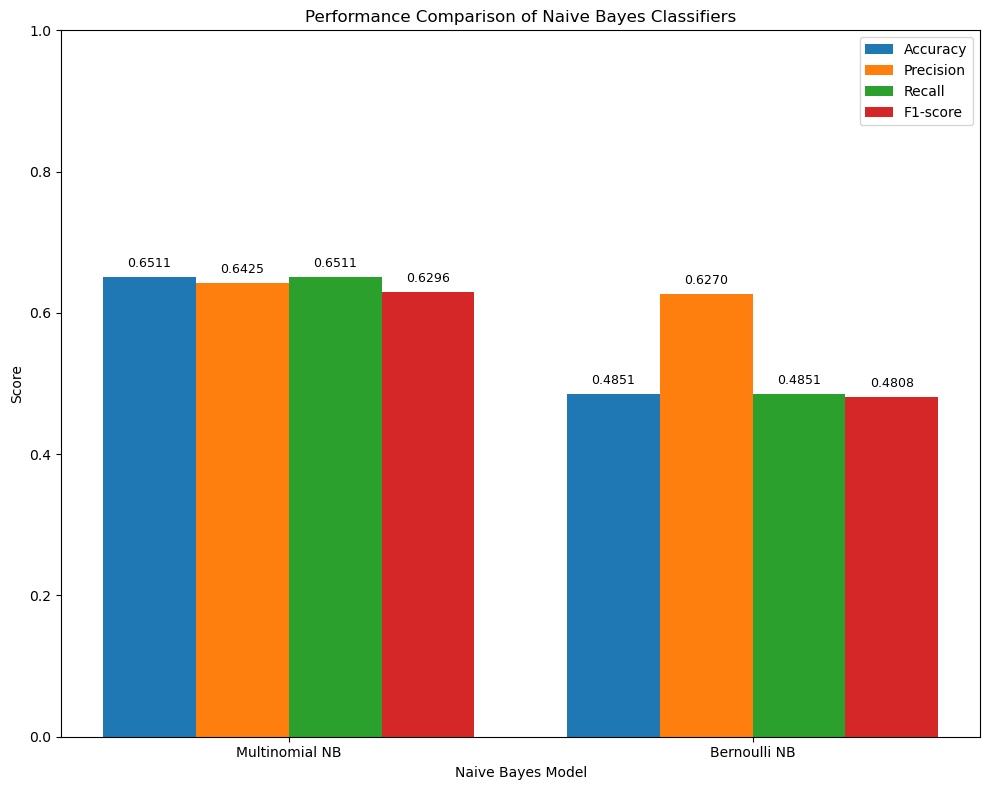

In [69]:
models = ["Multinomial NB", "Bernoulli NB"]

accuracy = [mnb_accuracy, bnb_accuracy]
precision = [mnb_precision, bnb_precision]
recall = [mnb_recall, bnb_recall]
f1 = [mnb_f1, bnb_f1]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 8))

# Create bars
bars1 = plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
bars2 = plt.bar(x - 0.5*width, precision, width, label="Precision")
bars3 = plt.bar(x + 0.5*width, recall, width, label="Recall")
bars4 = plt.bar(x + 1.5*width, f1, width, label="F1-score")

plt.xlabel("Naive Bayes Model")
plt.ylabel("Score")
plt.title("Performance Comparison of Naive Bayes Classifiers")

plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()

# Add values above each bar
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.01,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()



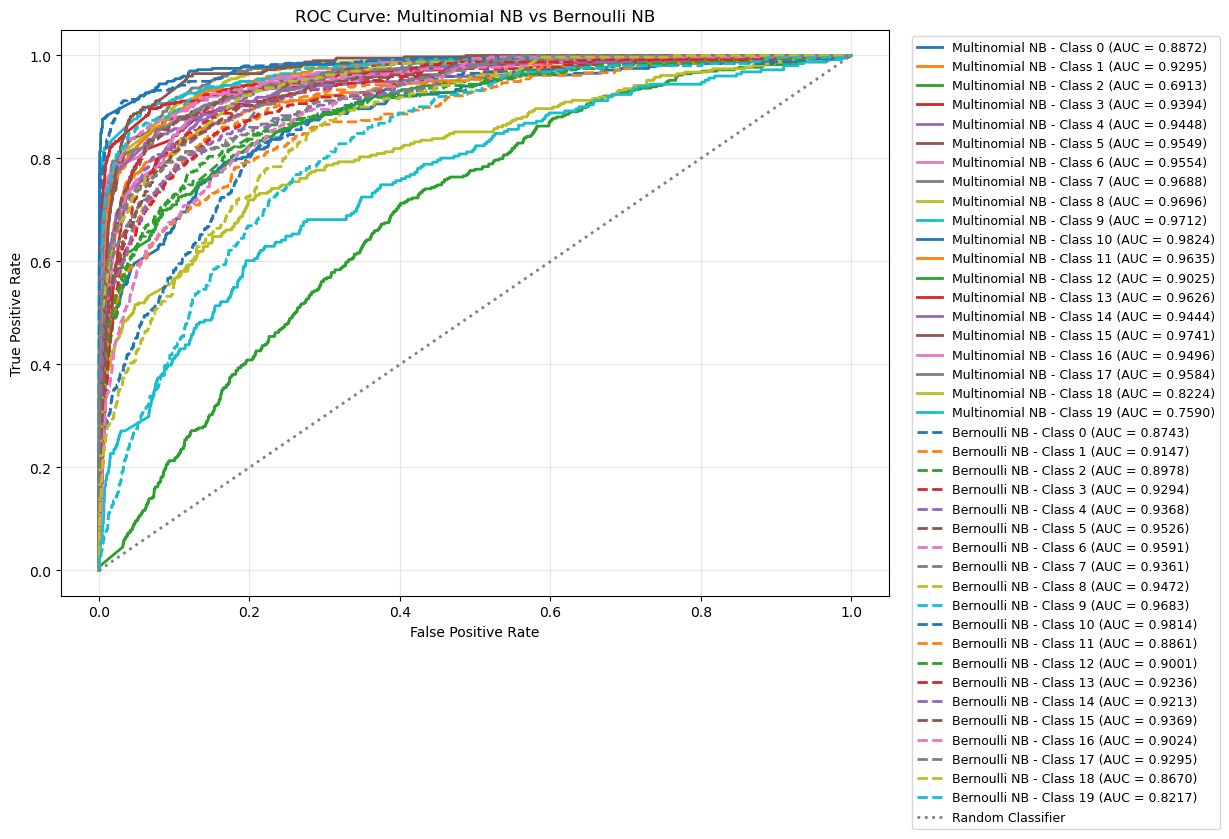

In [71]:
plt.figure(figsize=(16, 8))

# Multinomial NB ROC
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_mnb[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"Multinomial NB - Class {class_name} (AUC = {roc_auc:.4f})"
    )

# Bernoulli NB ROC
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_bnb[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linestyle="--",
        linewidth=2,
        label=f"Bernoulli NB - Class {class_name} (AUC = {roc_auc:.4f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle=":",
    linewidth=2,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Multinomial NB vs Bernoulli NB")

# Move legend outside the graph
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=9
)

plt.grid(alpha=0.3)

# Make space for the legend
plt.tight_layout(rect=[0, 0, 0.78, 1])

plt.show()
